In [16]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import os
import shutil
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import cv2
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
from tqdm import tqdm
from datetime import datetime

print("All imports successful!")

All imports successful!


In [17]:
# ── config ────────────────────────────────────────────────
FRAMES_FOLDER  = "/Users/iris/Desktop/ETH/DAS Project/camera-trap-gan/data/frames/FH102_02"
CSV_PATH       = "/Users/iris/Desktop/ETH/DAS Project/camera-trap-gan/data/Weinstein2018MEE_ground_truth.csv"
OUTPUT_FOLDER  = "/Users/iris/Desktop/ETH/DAS Project/camera-trap-gan/outputs/FH102_02_{timestamp}"
VIDEO_NAME     = "FH102_02"
timestamp = datetime.now().strftime("%Y%m%d_%H")
IMG_SIZE       = 256
BATCH_SIZE     = 32 ## 16
EPOCHS         = 10
LEARNING_RATE  = 0.001
LATENT_DIM     = 512
THRESHOLD_STD  = 2

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

device = torch.device("mps"  if torch.backends.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else "cpu")
# save config to text file so you know what settings this run used
config_summary = f"""
Run timestamp  : {timestamp}
Video          : {VIDEO_NAME}
Frames folder  : {FRAMES_FOLDER}
Image size     : {IMG_SIZE}
Batch size     : {BATCH_SIZE}
Epochs         : {EPOCHS}
Learning rate  : {LEARNING_RATE}
Latent dim     : {LATENT_DIM}
Threshold std  : {THRESHOLD_STD}
Device         : {device}
"""

with open(os.path.join(OUTPUT_FOLDER, "config.txt"), "w") as f:
    f.write(config_summary)

print(config_summary)



Run timestamp  : 20260314_22
Video          : FH102_02
Frames folder  : /Users/iris/Desktop/ETH/DAS Project/camera-trap-gan/data/frames/FH102_02
Image size     : 256
Batch size     : 32
Epochs         : 10
Learning rate  : 0.001
Latent dim     : 512
Threshold std  : 2
Device         : mps



In [18]:
df = pd.read_csv(CSV_PATH)

# peek at structure
print("CSV columns:", df.columns.tolist())
print(f"Total rows: {len(df)}")
print("\nFirst 10 rows:")
df.head(10)

CSV columns: ['Video', 'Frame', 'Truth']
Total rows: 39621

First 10 rows:


,Video,Frame,Truth
0,FH102_02,2,Negative
1,FH102_02,3,Negative
2,FH102_02,4,Negative
3,FH102_02,5,Negative
4,FH102_02,6,Negative
5,FH102_02,7,Negative
6,FH102_02,9,Negative
7,FH102_02,17,Negative
8,FH102_02,35,Negative
9,FH102_02,38,Negative


In [19]:
df_video = df[df['Video'] == VIDEO_NAME].copy()

print(f"Video: {VIDEO_NAME}")
print(f"Total frames in CSV : {len(df_video)}")
print(f"Positive (bird)     : {(df_video['Truth'] == 'Positive').sum()}")
print(f"Negative (normal)   : {(df_video['Truth'] == 'Negative').sum()}")

# build set of positive frame filenames
# CSV is 1-indexed → subtract 1 to match frame_00000.jpg
positive_frames = set(
    f"frame_{(row['Frame'] - 1):05d}.jpg"
    for _, row in df_video.iterrows()
    if row['Truth'] == 'Positive'
)

print(f"\nBird frames to find: {len(positive_frames)}")
print(f"Example filenames: {list(positive_frames)[:5]}")

Video: FH102_02
Total frames in CSV : 969
Positive (bird)     : 39
Negative (normal)   : 930

Bird frames to find: 33
Example filenames: ['frame_10926.jpg', 'frame_10922.jpg', 'frame_01019.jpg', 'frame_01023.jpg', 'frame_01020.jpg']


In [20]:
# ── 1. dataset ──────────────────────────────────────────────
class CameraTrapDataset(Dataset):
    def __init__(self, frames_folder, img_size=256, use_diff=True):
        self.frame_paths = sorted([
            os.path.join(frames_folder, f)
            for f in os.listdir(frames_folder)
            if f.endswith('.jpg')
        ])
        self.use_diff = use_diff
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5],
                                 [0.5, 0.5, 0.5])
        ])

    def __len__(self):
        return len(self.frame_paths)

    def __getitem__(self, idx):
        if self.use_diff and idx > 0:
            # load current and previous frame
            curr = cv2.imread(self.frame_paths[idx])
            prev = cv2.imread(self.frame_paths[idx - 1])
            curr = cv2.cvtColor(curr, cv2.COLOR_BGR2RGB)
            prev = cv2.cvtColor(prev, cv2.COLOR_BGR2RGB)
            # absolute difference — captures motion
            img = cv2.absdiff(curr, prev)
        else:
            # first frame or no diff mode
            img = cv2.imread(self.frame_paths[idx])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        return self.transform(img), self.frame_paths[idx]

# create dataset
dataset = CameraTrapDataset(FRAMES_FOLDER, img_size=IMG_SIZE, use_diff=True)
print(f"Total frames loaded: {len(dataset)}")

# quick sanity check — load one frame
sample_frame, sample_path = dataset[0]
print(f"Sample frame shape : {sample_frame.shape}")
print(f"Sample frame range : {sample_frame.min():.2f} to {sample_frame.max():.2f}")
print(f"Sample path        : {os.path.basename(sample_path)}")

Total frames loaded: 21593
Sample frame shape : torch.Size([3, 256, 256])
Sample frame range : -1.00 to 1.00
Sample path        : frame_00000.jpg


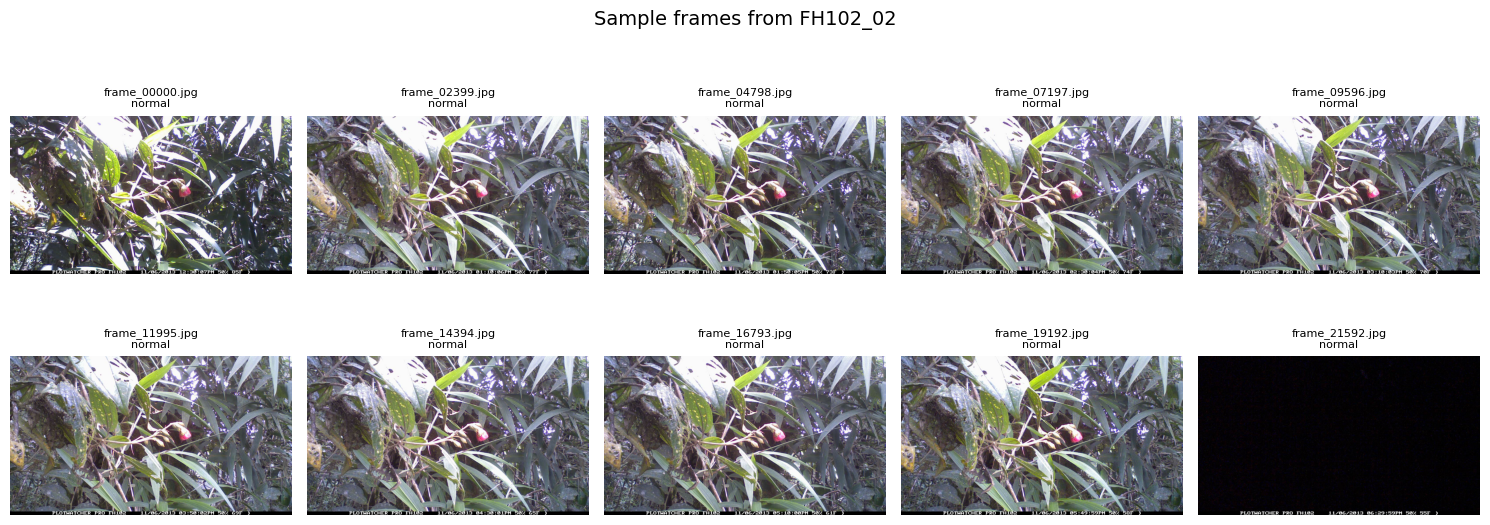

In [21]:
# ── 1.1 Sample Frames ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Sample frames from FH102_02", fontsize=14)

# pick 10 evenly spaced frames
indices = np.linspace(0, len(dataset)-1, 10, dtype=int)

for ax, idx in zip(axes.flatten(), indices):
    img = cv2.imread(dataset.frame_paths[idx])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    filename = os.path.basename(dataset.frame_paths[idx])
    is_bird = "BIRD" if filename in positive_frames else "normal"
    ax.imshow(img)
    ax.set_title(f"{filename}\n{is_bird}", fontsize=8,
                 color='green' if is_bird == "BIRD" else 'black')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [22]:
# ── 2. model ──────────────────────────────────────────────
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=512):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64,  kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(512 * 16 * 16, latent_dim)
        )
        self.decoder_fc = nn.Linear(latent_dim, 512 * 16 * 16)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64,  kernel_size=4, stride=2, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.ConvTranspose2d(64,  3,   kernel_size=4, stride=2, padding=1), nn.Tanh()
        )

    def forward(self, x):
        z = self.encoder(x)
        x = self.decoder_fc(z)
        x = x.view(-1, 512, 16, 16)
        return self.decoder(x)

    def anomaly_score(self, x):
        return torch.mean((x - self.forward(x)) ** 2, dim=[1, 2, 3])

model = Autoencoder(latent_dim=LATENT_DIM).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model ready — {total_params:,} parameters")

Model ready — 139,864,579 parameters


In [ ]:
# ── 3. train ──────────────────────────────────────────────
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=0)
optimizer    = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion    = nn.MSELoss()
losses       = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0

    for frames, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}",
                          leave=False):
        frames = frames.to(device)
        optimizer.zero_grad()
        loss = criterion(model(frames), frames)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    losses.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{EPOCHS}]  Loss: {epoch_loss:.4f}")

    if (epoch + 1) % 5 == 0:
        torch.save(model.state_dict(),
                   os.path.join(OUTPUT_FOLDER, f"model_epoch{epoch+1}.pth"))
        print(f"  → checkpoint saved")

torch.save(model.state_dict(), os.path.join(OUTPUT_FOLDER, "model.pth"))
print("\nTraining complete!")


Epoch [1/10]  Loss: 0.0206


Epoch [2/10]  Loss: 0.0055


Epoch 3/10:  58%|█████▊    | 389/675 [05:51<04:27,  1.07it/s]

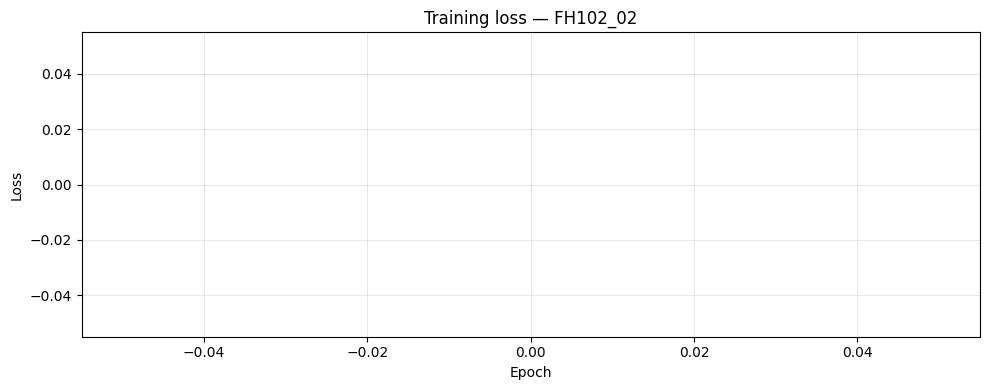

IndexError: list index out of range

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(losses, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss — FH102_02")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "loss_curve.png"))
plt.show()
print(f"Final loss: {losses[-1]:.4f}")

In [ ]:
# ── 4. detect ──────────────────────────────────────────────
# IMPORTANT: use same dataset with use_diff=True
# shuffle=False preserves time order for temporal analysis
detect_loader = DataLoader(dataset, batch_size=BATCH_SIZE,
                           shuffle=False, num_workers=0)
all_scores = []
all_paths  = []

model.eval()
with torch.no_grad():
    for frames, paths in tqdm(detect_loader, desc="Scoring frames"):
        frames = frames.to(device)
        scores = model.anomaly_score(frames)
        all_scores.extend(scores.cpu().numpy())
        all_paths.extend(paths)

scores_np = np.array(all_scores)
threshold = scores_np.mean() + THRESHOLD_STD * scores_np.std()

print(f"Scored {len(scores_np)} frames")
print(f"Mean      : {scores_np.mean():.4f}")
print(f"Std       : {scores_np.std():.4f}")
print(f"Threshold : {threshold:.4f}")
print(f"Flagged   : {(scores_np > threshold).sum()} frames")

# sanity check — confirm using diff dataset
print(f"\nUsing frame differencing: {dataset.use_diff}")
print(f"First scored path: {os.path.basename(all_paths[0])}")

Scoring frames: 100%|██████████| 675/675 [04:37<00:00,  2.43it/s]

Scored 21593 frames
Mean      : 0.0028
Std       : 0.0022
Threshold : 0.0094
Flagged   : 441 frames


In [ ]:
# ── 4. evaluate ──────────────────────────────────────────────

# build label lookup from CSV
# positive_frames = set of bird filenames
# negative_frames = set of confirmed normal filenames
negative_frames = set(
    f"frame_{(row['Frame'] - 1):05d}.jpg"
    for _, row in df_video.iterrows()
    if row['Truth'] == 'Negative'
)

# categorise every frame
labelled_indices   = []
unlabelled_indices = []
y_true_labelled    = []
y_pred_labelled    = []

for i, (score, path) in enumerate(zip(all_scores, all_paths)):
    filename   = os.path.basename(path)
    is_flagged = 1 if score > threshold else 0

    if filename in positive_frames:
        # confirmed bird
        labelled_indices.append(i)
        y_true_labelled.append(1)
        y_pred_labelled.append(is_flagged)
    elif filename in negative_frames:
        # confirmed normal
        labelled_indices.append(i)
        y_true_labelled.append(0)
        y_pred_labelled.append(is_flagged)
    else:
        # unlabelled — exclude from metrics
        unlabelled_indices.append(i)

y_true_labelled = np.array(y_true_labelled)
y_pred_labelled = np.array(y_pred_labelled)

# metrics on labelled frames only
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true_labelled, y_pred_labelled,
    average='binary', zero_division=0)
cm = confusion_matrix(y_true_labelled, y_pred_labelled)

print(f"{'='*55}")
print(f"  RESULTS — {VIDEO_NAME}")
print(f"{'='*55}")
print(f"  Total frames      : {len(all_paths)}")
print(f"  Labelled frames   : {len(y_true_labelled)}  ← used for metrics")
print(f"  Unlabelled frames : {len(unlabelled_indices)}  ← excluded from metrics")
print(f"  Bird frames       : {y_true_labelled.sum()}")
print(f"  Normal frames     : {(y_true_labelled == 0).sum()}")
print(f"  Flagged frames    : {y_pred_labelled.sum()}")
print(f"")
print(f"  Precision         : {precision:.3f}  (of flagged labelled, how many are birds?)")
print(f"  Recall            : {recall:.3f}  (of all birds, how many found?)")
print(f"  F1 score          : {f1:.3f}")
print(f"\nConfusion matrix (labelled frames only):")
print(f"                  Predicted")
print(f"                  Normal   Bird")
print(f"  Actual Normal   {cm[0][0]:6d}   {cm[0][1]:4d}")
print(f"  Actual Bird     {cm[1][0]:6d}   {cm[1][1]:4d}")
print(f"\nNote: {len(unlabelled_indices)} unlabelled frames excluded from metrics")
print(f"      their predictions are still made but not evaluated")

  RESULTS — FH102_02
  Total frames      : 21593
  Labelled frames   : 958  ← used for metrics
  Unlabelled frames : 20635  ← excluded from metrics
  Bird frames       : 33
  Normal frames     : 925
  Flagged frames    : 234

  Precision         : 0.090  (of flagged labelled, how many are birds?)
  Recall            : 0.636  (of all birds, how many found?)
  F1 score          : 0.157

Confusion matrix (labelled frames only):
                  Predicted
                  Normal   Bird
  Actual Normal      712    213
  Actual Bird         12     21

Note: 20635 unlabelled frames excluded from metrics
      their predictions are still made but not evaluated


AUC-ROC: 0.803


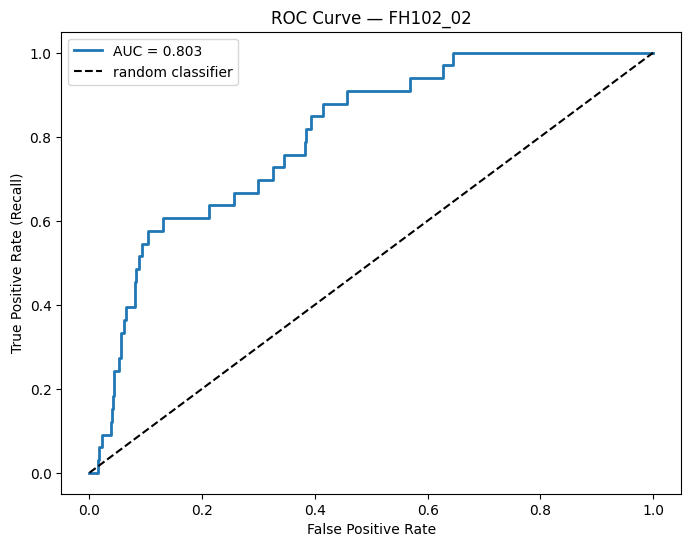

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

# only on labelled frames
scores_labelled = np.array([all_scores[i] for i in labelled_indices])

auc = roc_auc_score(y_true_labelled, scores_labelled)
print(f"AUC-ROC: {auc:.3f}")

# plot ROC curve
fpr, tpr, thresholds = roc_curve(y_true_labelled, scores_labelled)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'AUC = {auc:.3f}')
plt.plot([0,1], [0,1], 'k--', label='random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — FH102_02')
plt.legend()
plt.savefig(os.path.join(OUTPUT_FOLDER, "roc_curve.png"))
plt.show()

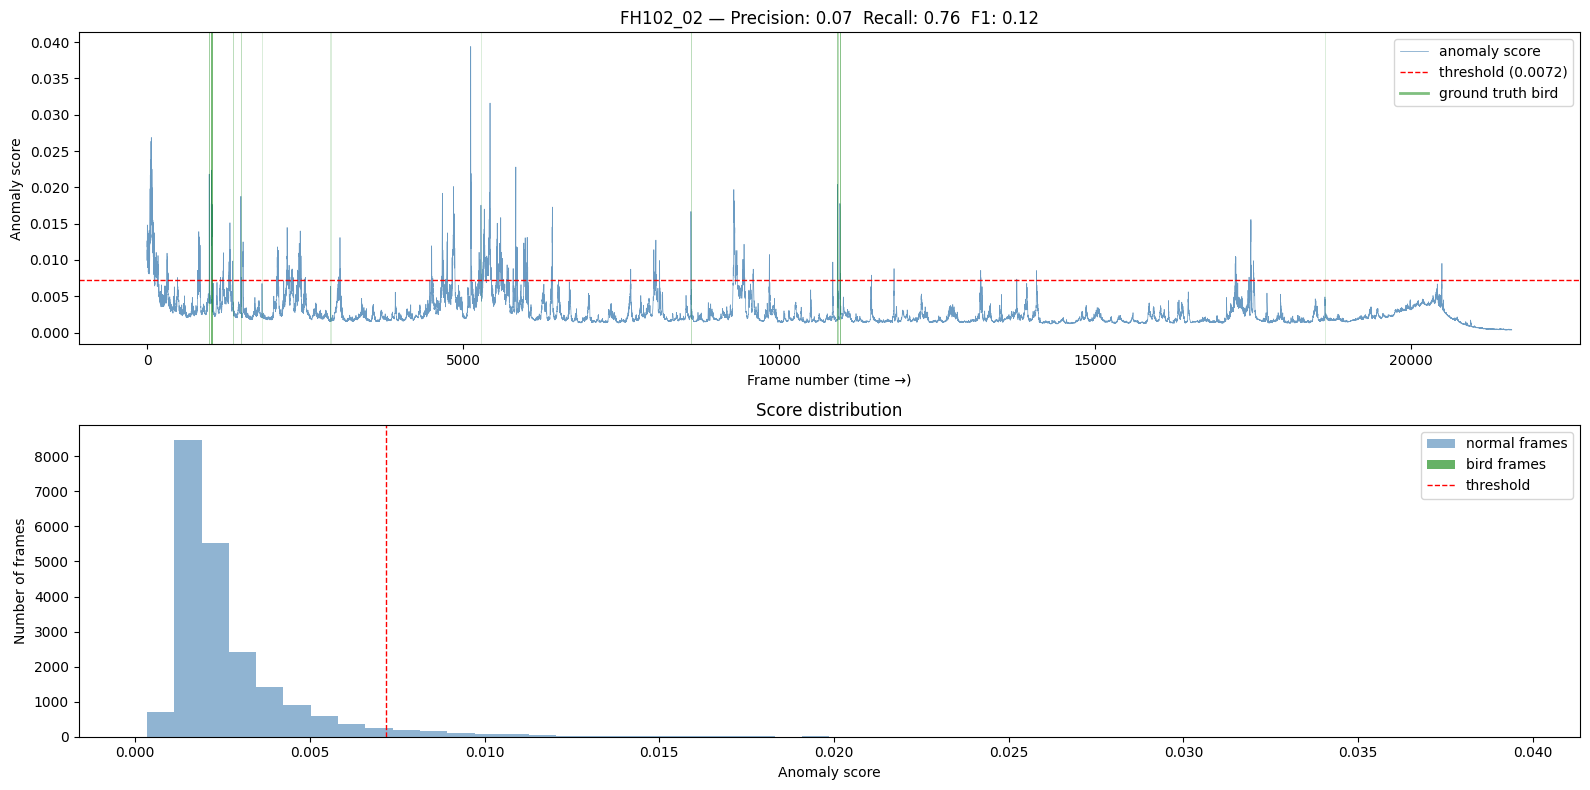

In [ ]:
# ── 5. plot results ──────────────────────────────────────────────
bird_indices = [i for i, p in enumerate(all_paths)
                if os.path.basename(p) in positive_frames]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8))

# scores over time
ax1.plot(scores_np, linewidth=0.5, color='steelblue', alpha=0.8, label='anomaly score')
ax1.axhline(y=threshold, color='red', linestyle='--', linewidth=1,
            label=f'threshold ({threshold:.4f})')
for idx in bird_indices:
    ax1.axvline(x=idx, color='green', alpha=0.2, linewidth=0.5)
ax1.plot([], [], color='green', alpha=0.5, linewidth=2, label='ground truth bird')
ax1.set_xlabel("Frame number (time →)")
ax1.set_ylabel("Anomaly score")
ax1.set_title(f"{VIDEO_NAME} — Precision: {precision:.2f}  Recall: {recall:.2f}  F1: {f1:.2f}")
ax1.legend()

# histogram
ax2.hist(scores_np[y_true == 0], bins=50, alpha=0.6,
         color='steelblue', label='normal frames')
ax2.hist(scores_np[y_true == 1], bins=50, alpha=0.6,
         color='green', label='bird frames')
ax2.axvline(x=threshold, color='red', linestyle='--',
            linewidth=1, label=f'threshold')
ax2.set_xlabel("Anomaly score")
ax2.set_ylabel("Number of frames")
ax2.set_title("Score distribution")
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "results.png"))
plt.show()

Top 20 saved to /Users/iris/Desktop/ETH/DAS Project/camera-trap-gan/outputs/FH102_02/suspicious_frames
Filenames labelled BIRD or normal


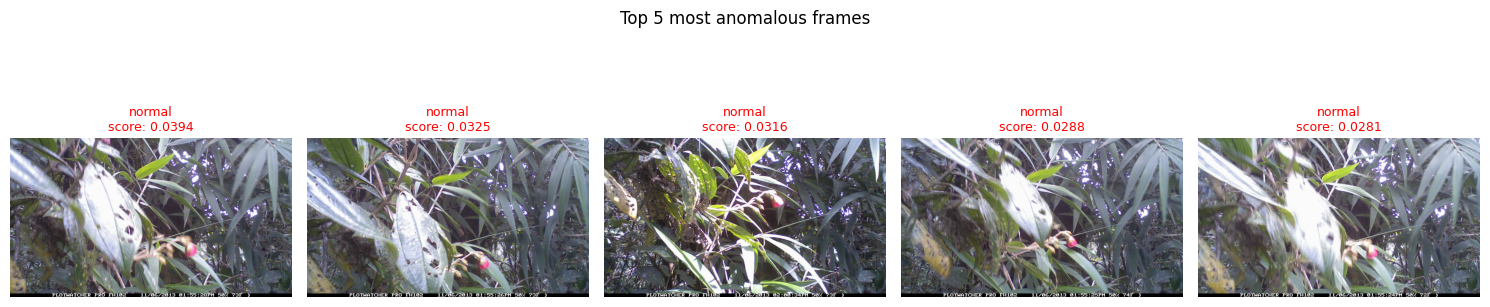

In [ ]:
# ── 6. save detected results ──────────────────────────────────────────────
ranked = sorted(zip(all_scores, all_paths), reverse=True)
suspicious_folder = os.path.join(OUTPUT_FOLDER, "suspicious_frames")
os.makedirs(suspicious_folder, exist_ok=True)

for f in os.listdir(suspicious_folder):
    os.remove(os.path.join(suspicious_folder, f))

for i, (score, path) in enumerate(ranked[:20]):
    filename = os.path.basename(path)
    is_bird  = "BIRD" if filename in positive_frames else "normal"
    dest = os.path.join(suspicious_folder,
           f"rank{i+1:02d}_{is_bird}_score{score:.4f}_{filename}")
    shutil.copy(path, dest)

print(f"Top 20 saved to {suspicious_folder}")
print("Filenames labelled BIRD or normal")

# show top 5 suspicious frames inline
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
fig.suptitle("Top 5 most anomalous frames", fontsize=12)

for ax, (score, path) in zip(axes, ranked[:5]):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    filename = os.path.basename(path)
    is_bird  = "BIRD" if filename in positive_frames else "normal"
    ax.imshow(img)
    ax.set_title(f"{is_bird}\nscore: {score:.4f}", fontsize=9,
                 color='green' if is_bird == 'BIRD' else 'red')
    ax.axis('off')

plt.tight_layout()
plt.show()